# TITLE
# Amazon Sales Data Analysis using Jupyter Notebook

The current project aims at analyzing the sales data generated by Amazon to discover insightful information and knowledge that can be used to understand the business operations. The analysis is performed using Python and Jupyter Notebook, applying data preprocessing, visualization, and statistical techniques to understand business performance and support data-driven decision-making.


# OBJECTIVE

The key objective of the current project is to conduct an in-depth analysis of the sales dataset provided by Amazon. The task is to examine, cleanse, process, and visualize the available data in order to generate useful insights.

By conducting the above analysis, we will be able to achieve the following objectives:

1. Analyze sales trends over time.
2. Find best-selling product categories.
3. Examine regional distribution of sales.
4. Discover correlations between various factors.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# DATASET DESCRIPTION

In this study, the dataset utilized includes the Amazon Sales Report Dataset, which contains comprehensive information on customers' transactions, including details related to orders, products, and shipping.

Some of the important attributes that feature in the dataset are:

1. Order Details: Order ID, Date.
2. Product Details: Category, SKU, Style, Size.
3. Sales Information: Amount, Quantity.
4. Order Status: Delivered, Cancelled, Returned.
5. Shipping Information: City, State, Country.
6. Further Information: Sales Channel, Fulfillment, Promotion.

The dataset used provides all the information about sales activity in the organization and can be used for business and marketing analysis.

In [2]:
df = pd.read_csv("Amazon Sale Report.csv", low_memory=False)

In [3]:
print(df.shape)
df.head(250)

(128975, 24)


,index,Order ID,Date,Status,Fulfilment,Sales Channel,ship-service-level,Style,SKU,Category,...,currency,Amount,ship-city,ship-state,ship-postal-code,ship-country,promotion-ids,B2B,fulfilled-by,Unnamed: 22
0,0,405-8078784-5731545,04-30-22,Cancelled,Merchant,Amazon.in,Standard,SET389,SET389-KR-NP-S,Set,...,INR,647.62,MUMBAI,MAHARASHTRA,400081.0,IN,NaN,False,Easy Ship,NaN
1,1,171-9198151-1101146,04-30-22,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,JNE3781,JNE3781-KR-XXXL,kurta,...,INR,406.00,BENGALURU,KARNATAKA,560085.0,IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship,NaN
2,2,404-0687676-7273146,04-30-22,Shipped,Amazon,Amazon.in,Expedited,JNE3371,JNE3371-KR-XL,kurta,...,INR,329.00,NAVI MUMBAI,MAHARASHTRA,410210.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,True,NaN,NaN
3,3,403-9615377-8133951,04-30-22,Cancelled,Merchant,Amazon.in,Standard,J0341,J0341-DR-L,Western Dress,...,INR,753.33,PUDUCHERRY,PUDUCHERRY,605008.0,IN,NaN,False,Easy Ship,NaN
4,4,407-1069790-7240320,04-30-22,Shipped,Amazon,Amazon.in,Expedited,JNE3671,JNE3671-TU-XXXL,Top,...,INR,574.00,CHENNAI,TAMIL NADU,600073.0,IN,NaN,False,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
245,245,408-9321153-0591557,04-30-22,Shipped,Amazon,Amazon.in,Expedited,JNE3405,JNE3405-KR-XL,kurta,...,INR,399.00,BENGALURU,KARNATAKA,560029.0,IN,NaN,False,NaN,NaN
246,246,404-0696150-3898703,04-30-22,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,J0348,J0348-SET-S,Set,...,INR,499.00,PUNE,MAHARASHTRA,411037.0,IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship,NaN
247,247,406-7586136-6520337,04-30-22,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,J0399,J0399-DR-M,Western Dress,...,INR,791.00,DEHRADUN,UTTARAKHAND,248009.0,IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship,NaN
248,248,407-6146457-8788352,04-30-22,Shipped,Amazon,Amazon.in,Expedited,JNE3797,JNE3797-KR-M,Western Dress,...,INR,725.00,GAYA,BIHAR,823001.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,False,NaN,NaN


# DATA OVERVIEW

Once the dataset was loaded, there was an initial observation carried out in order to get familiar with the data and its components.

Firstly, there were a few rows of the dataset printed to have some idea about the data. Moreover, the dimension of the dataset was observed to see how many observations and variables are present in it.

In [4]:
pd.set_option('display.max_columns', None)
df.head(250)

,index,Order ID,Date,Status,Fulfilment,Sales Channel,ship-service-level,Style,SKU,Category,Size,ASIN,Courier Status,Qty,currency,Amount,ship-city,ship-state,ship-postal-code,ship-country,promotion-ids,B2B,fulfilled-by,Unnamed: 22
0,0,405-8078784-5731545,04-30-22,Cancelled,Merchant,Amazon.in,Standard,SET389,SET389-KR-NP-S,Set,S,B09KXVBD7Z,NaN,0,INR,647.62,MUMBAI,MAHARASHTRA,400081.0,IN,NaN,False,Easy Ship,NaN
1,1,171-9198151-1101146,04-30-22,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,JNE3781,JNE3781-KR-XXXL,kurta,3XL,B09K3WFS32,Shipped,1,INR,406.00,BENGALURU,KARNATAKA,560085.0,IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship,NaN
2,2,404-0687676-7273146,04-30-22,Shipped,Amazon,Amazon.in,Expedited,JNE3371,JNE3371-KR-XL,kurta,XL,B07WV4JV4D,Shipped,1,INR,329.00,NAVI MUMBAI,MAHARASHTRA,410210.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,True,NaN,NaN
3,3,403-9615377-8133951,04-30-22,Cancelled,Merchant,Amazon.in,Standard,J0341,J0341-DR-L,Western Dress,L,B099NRCT7B,NaN,0,INR,753.33,PUDUCHERRY,PUDUCHERRY,605008.0,IN,NaN,False,Easy Ship,NaN
4,4,407-1069790-7240320,04-30-22,Shipped,Amazon,Amazon.in,Expedited,JNE3671,JNE3671-TU-XXXL,Top,3XL,B098714BZP,Shipped,1,INR,574.00,CHENNAI,TAMIL NADU,600073.0,IN,NaN,False,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
245,245,408-9321153-0591557,04-30-22,Shipped,Amazon,Amazon.in,Expedited,JNE3405,JNE3405-KR-XL,kurta,XL,B081WT6GG7,Shipped,1,INR,399.00,BENGALURU,KARNATAKA,560029.0,IN,NaN,False,NaN,NaN
246,246,404-0696150-3898703,04-30-22,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,J0348,J0348-SET-S,Set,S,B09HNSNWRH,Shipped,1,INR,499.00,PUNE,MAHARASHTRA,411037.0,IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship,NaN
247,247,406-7586136-6520337,04-30-22,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,J0399,J0399-DR-M,Western Dress,M,B09SDYL6L2,Shipped,1,INR,791.00,DEHRADUN,UTTARAKHAND,248009.0,IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship,NaN
248,248,407-6146457-8788352,04-30-22,Shipped,Amazon,Amazon.in,Expedited,JNE3797,JNE3797-KR-M,Western Dress,M,B09SDY8DCT,Shipped,1,INR,725.00,GAYA,BIHAR,823001.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,False,NaN,NaN


In [5]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 128975 entries, 0 to 128974
Data columns (total 24 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   index               128975 non-null  int64  
 1   Order ID            128975 non-null  object 
 2   Date                128975 non-null  object 
 3   Status              128975 non-null  object 
 4   Fulfilment          128975 non-null  object 
 5   Sales Channel       128975 non-null  object 
 6   ship-service-level  128975 non-null  object 
 7   Style               128975 non-null  object 
 8   SKU                 128975 non-null  object 
 9   Category            128975 non-null  object 
 10  Size                128975 non-null  object 
 11  ASIN                128975 non-null  object 
 12  Courier Status      122103 non-null  object 
 13  Qty                 128975 non-null  int64  
 14  currency            121180 non-null  object 
 15  Amount              121180 non-nul

,index,Qty,Amount,ship-postal-code
count,128975.000000,128975.000000,121180.000000,128942.000000
mean,64487.000000,0.904431,648.561465,463966.236509
std,37232.019822,0.313354,281.211687,191476.764941
min,0.000000,0.000000,0.000000,110001.000000
25%,32243.500000,1.000000,449.000000,382421.000000
50%,64487.000000,1.000000,605.000000,500033.000000
75%,96730.500000,1.000000,788.000000,600024.000000
max,128974.000000,15.000000,5584.000000,989898.000000


# EXPLORATORY DATA ANALYSIS (EDA)

Exploratory Data Analysis (EDA) was conducted to get insights into the dataset. It includes understanding the types of data, looking out for any missing values, and studying statistics.

To do this, we have made use of functions like 'info()' which tells us about the types of data and whether there are any nulls. Also, we have used the 'describe()' function to know the statistical information including mean, minimum, maximum, and standard deviation.


# DATA PREPROCESSING

It is an important process to enhance data quality. The following processes were carried out:

1. Cleaning of the column names by removing the extra spaces and making them lowercase.
2. Dealing with missing values through removal of incomplete rows.
3. Correction of data inconsistencies.

This process ensures that the data is in order.

In [6]:
df.columns = df.columns.str.strip().str.lower()

df = df.dropna()

print(df.shape)
df.head(250)

(19379, 24)


,index,order id,date,status,fulfilment,sales channel,ship-service-level,style,sku,category,size,asin,courier status,qty,currency,amount,ship-city,ship-state,ship-postal-code,ship-country,promotion-ids,b2b,fulfilled-by,unnamed: 22
49051,49051,408-4858463-2356347,05-31-22,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,J0385,J0385-KR-M,kurta,M,B09YYNG98D,Shipped,1,INR,888.0,RAJAHMUNDRY,ANDHRA PRADESH,533126.0,IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship,False
49077,49077,402-7697834-2682766,05-31-22,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,JNE3654,JNE3654-TP-XXL,Top,XXL,B09B3GWVJ9,Shipped,1,INR,371.0,CHENNAI,TAMIL NADU,600042.0,IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship,False
49081,49081,402-7031777-0396341,05-31-22,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,JNE3798,JNE3798-KR-XS,Western Dress,XS,B09SDY7MHD,Shipped,1,INR,771.0,NEDUMANGAD,KERALA,695541.0,IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship,False
49082,49082,408-1235521-4337163,05-31-22,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,J0152,J0152-DR-L,Western Dress,L,B08V197XLZ,Shipped,1,INR,0.0,LEH,JAMMU & KASHMIR,194101.0,IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship,False
49083,49083,403-3845187-4421165,05-31-22,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,J0157,J0157-DR-XL,Western Dress,XL,B098316HXL,Shipped,1,INR,690.0,PIMPRI CHINCHWAD,MAHARASHTRA,411027.0,IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
50181,50181,408-0268386-3341140,05-31-22,Shipped - Returned to Seller,Merchant,Amazon.in,Standard,JNE1233,JNE1233-BLUE-KR-031-XXXL,kurta,3XL,B07GPGP46N,Shipped,1,INR,382.0,GURUGRAM,HARYANA,122003.0,IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship,False
50183,50183,403-4123598-1642707,05-31-22,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,JNE3567,JNE3567-KR-XL,kurta,XL,B08KRTXC2Y,Shipped,1,INR,399.0,Hyderabad,TELANGANA,500033.0,IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship,False
50188,50188,403-1327057-9311554,05-31-22,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,JNE3787,JNE3787-KR-XXXL,kurta,3XL,B09RKCC8WS,Shipped,1,INR,487.0,COIMBATORE,TAMIL NADU,641025.0,IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship,False
50189,50189,403-1327057-9311554,05-31-22,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,JNE3546,JNE3546-KR-XXXL,kurta,3XL,B09B2F5N2H,Shipped,1,INR,487.0,COIMBATORE,TAMIL NADU,641025.0,IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship,False


In [7]:
df['date'] = pd.to_datetime(df['date'], format='%m-%d-%y', errors='coerce')

df['month'] = df['date'].dt.month

df[['date', 'month']].head(250)

,date,month
49051,2022-05-31,5
49077,2022-05-31,5
49081,2022-05-31,5
49082,2022-05-31,5
49083,2022-05-31,5
...,...,...
50181,2022-05-31,5
50183,2022-05-31,5
50188,2022-05-31,5
50189,2022-05-31,5


# FEATURE ENGINEERING

The date column was transformed to a datetime datatype for analysis through time. As there were various formats for dates in addition to some errors in the dates, suitable methods were used for the transformation.

Another column named 'month' was formed based on the information found in the date column.

# RESEARCH QUESTIONS

The research questions that will inform the current analysis include the following:

1. In what way do the sales change over time?
2. During which months is the level of sales highest?
3. What kinds of products are responsible for bringing in the largest part of sales income?
4. What is the distribution of sales according to geographical regions?
5. What correlations can be observed among variables?

## Sales Trend Over Time

This visualization represents how total sales change over time using a line graph. It helps in identifying trends, patterns, and fluctuations in sales performance.

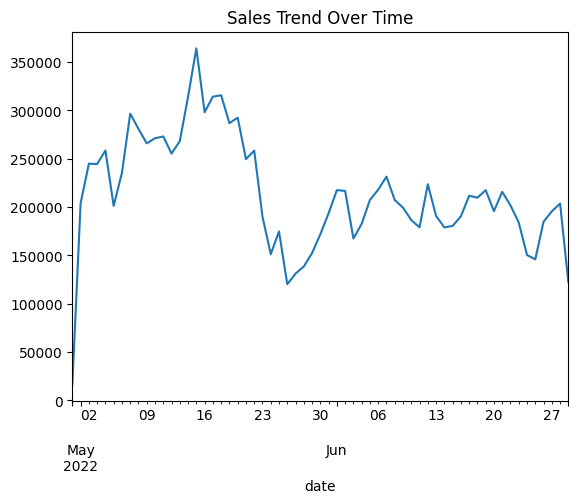

In [8]:
df.groupby('date')['amount'].sum().plot()
plt.title("Sales Trend Over Time")
plt.show()

**Insight & Answer:**

The line graph shows how sales vary over time. It helps in identifying periods of high and low sales. An increasing trend indicates business growth, while fluctuations suggest seasonal or external influences on sales.

## Monthly Sales Analysis

This visualization analyzes total sales across different months to identify seasonal patterns.

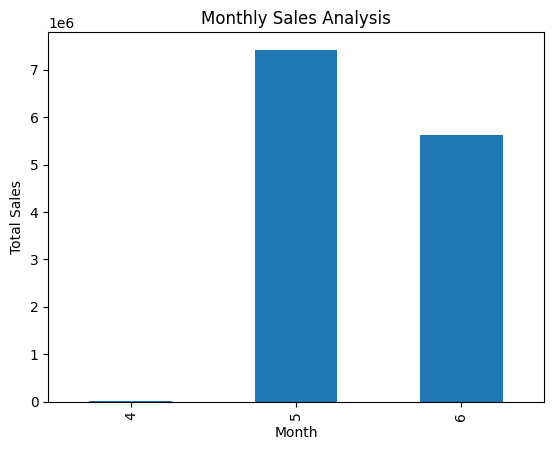

In [9]:
df.groupby('month')['amount'].sum().plot(kind='bar')
plt.title("Monthly Sales Analysis")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.show()

**Insight & Answer:**

The bar chart shows sales for each month, allowing us to identify peak months. Certain months generate higher sales, indicating seasonal demand and customer purchasing trends.

## Category-wise Sales Analysis

This visualization compares sales across different product categories.

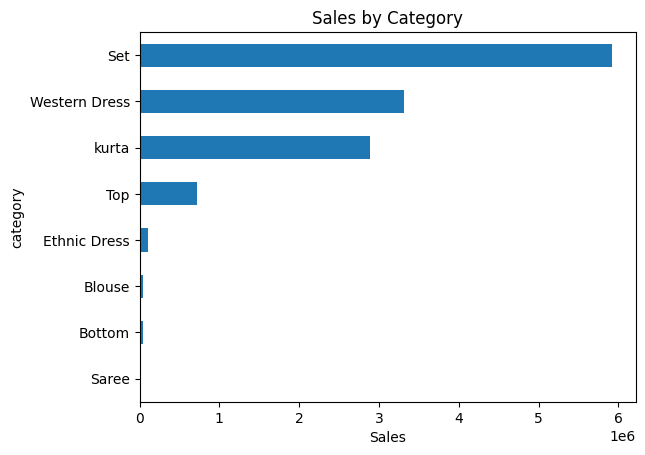

In [10]:
df.groupby('category')['amount'].sum().sort_values().plot(kind='barh')
plt.title("Sales by Category")
plt.xlabel("Sales")
plt.show()

**Insight & Answer:**

Some product categories contribute significantly more to total revenue. This helps identify high-performing categories and areas where improvement is needed.

## Sales Distribution

This visualization shows how sales values are distributed across transactions.

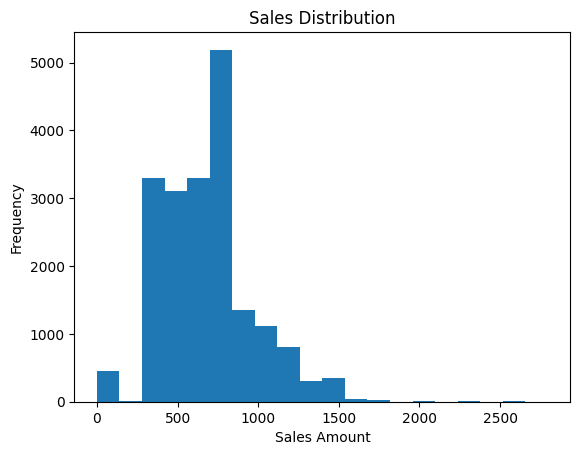

In [11]:
df['amount'].plot(kind='hist', bins=20)
plt.title("Sales Distribution")
plt.xlabel("Sales Amount")
plt.show()

**Insight & Answer:**

The histogram shows the frequency of different sales values. Most transactions fall within a certain range, while a few high-value transactions are observed.

## Outlier Analysis

This visualization identifies extreme values in sales data using a box plot.

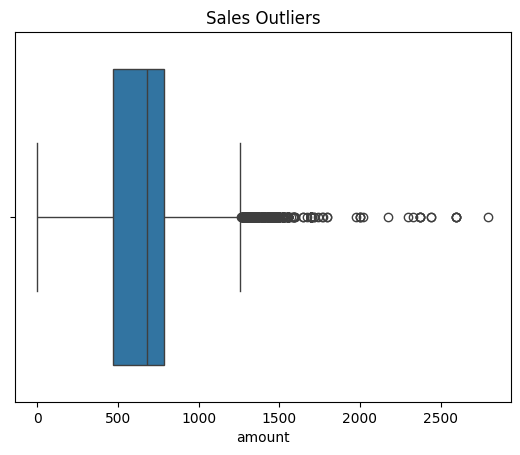

In [12]:
import seaborn as sns

sns.boxplot(x=df['amount'])
plt.title("Sales Outliers")
plt.show()

**Insight & Answer:**

The box plot highlights the presence of outliers in the dataset. These extreme values may represent unusually high transactions and should be analyzed carefully.

## Correlation Analysis

This visualization shows relationships between numerical variables using a heatmap.

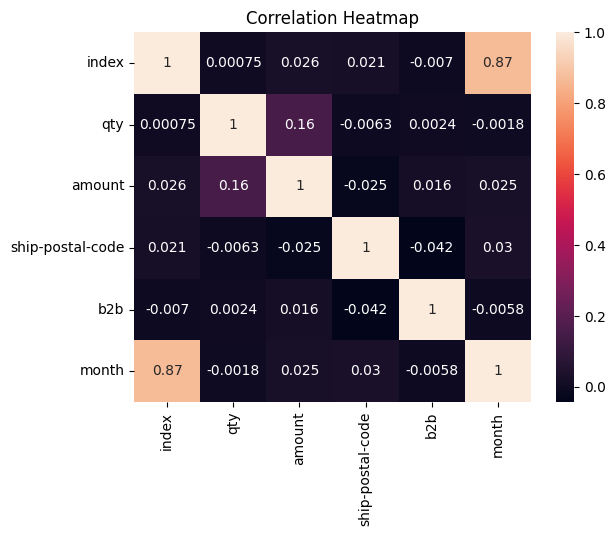

In [13]:
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.title("Correlation Heatmap")
plt.show()

**Insight & Answer:**

The heatmap displays correlations between variables. Strong correlations indicate relationships that influence sales performance and business outcomes.

## Top 10 Products

This visualization identifies the top-performing products based on total sales.

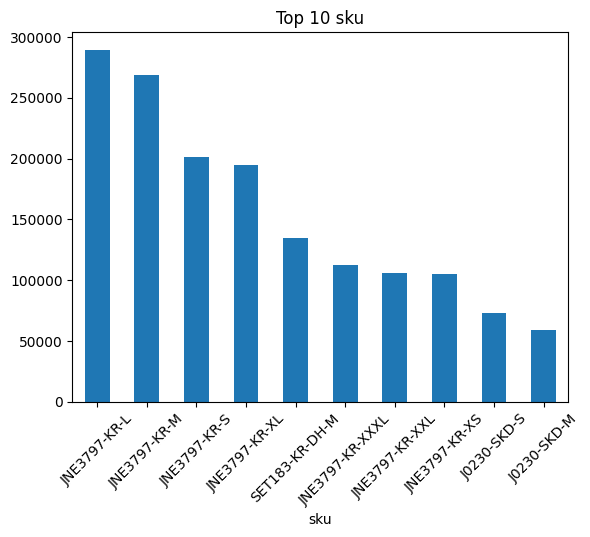

In [14]:
col = 'sku'   # change this after checking df.column

df.groupby(col)['amount'].sum().sort_values(ascending=False).head(10).plot(kind='bar')

plt.title(f"Top 10 {col}")
plt.xticks(rotation=45)
plt.show()

**Insight & Answer:**

The chart shows the products with the highest sales. These products are the most popular among customers and contribute significantly to overall revenue.

## Order Status Analysis

This visualization shows the distribution of different order statuses such as delivered, cancelled, and returned.

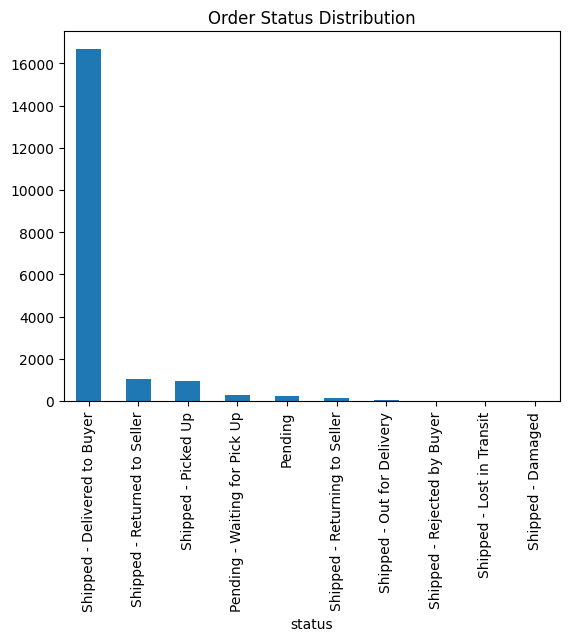

In [15]:
df['status'].value_counts().plot(kind='bar')
plt.title("Order Status Distribution")
plt.show()

**Insight & Answer:**

Most orders are successfully delivered, while a smaller portion is cancelled or returned. This helps in evaluating operational efficiency and customer satisfaction.

## Sales by State

This visualization analyzes sales distribution across different states.

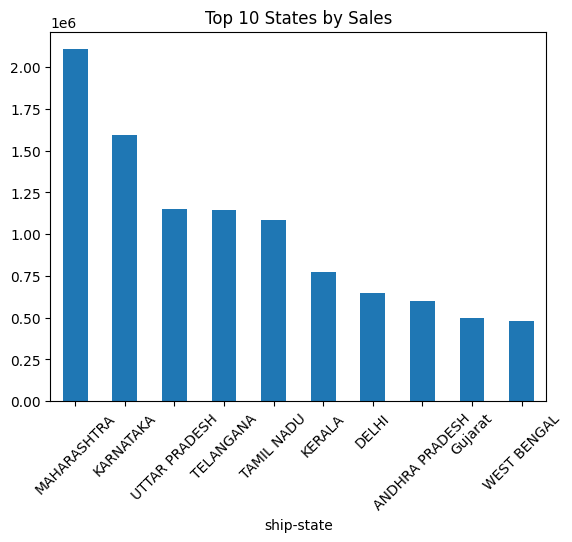

In [16]:
df.groupby('ship-state')['amount'].sum().sort_values(ascending=False).head(10).plot(kind='bar')

plt.title("Top 10 States by Sales")
plt.xticks(rotation=45)
plt.show()

**Insight & Answer:**

Sales are concentrated in certain states, indicating strong regional demand. This helps businesses target high-performing regions for marketing and expansion.

## Category Contribution

This visualization shows the percentage share of each category in total sales.

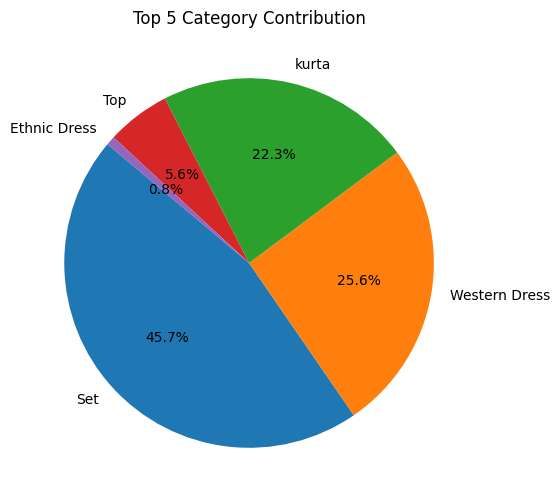

In [17]:
import matplotlib.pyplot as plt

# Get top 5 categories
data = df.groupby('category')['amount'].sum().sort_values(ascending=False).head(5)

plt.figure(figsize=(6,6))

plt.pie(
    data,
    labels=data.index,
    autopct='%1.1f%%',
    startangle=140
)

plt.title("Top 5 Category Contribution")
plt.show()

**Insight & Answer:**

The pie chart highlights how sales are distributed among categories. A few categories dominate the revenue, indicating their importance in overall business performance.

# KEY INSIGHTS

1. Sales exhibit fluctuations over time with clear trends.
2. Some months produce more sales, suggesting seasonality.
3. There are some product groups that produce most sales.
4. Sales tend to be clustered in certain locations.
5. Distribution of data suggests presence of large-value sales.
6. Variable relationships suggest influential factors.


# CONCLUSION

In this study, data from Amazon sales were analyzed to derive significant findings concerning trends in sales, product performance, and geographical locations.

From the analysis, seasonal trends, profitable products, and geographical regions that contribute to profit have been derived. These insights can be utilized by firms to make better decisions and formulate appropriate marketing strategies.

Generally, this study shows how data analysis plays an essential role in enhancing business performance.